loss: -0.24606217375101408
[[0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]]
[[0.06299956 0.06299956 0.06299956]
 [0.17125055 0.06299956 0.06299956]
 [0.17125055 0.17125055 0.17125055]]


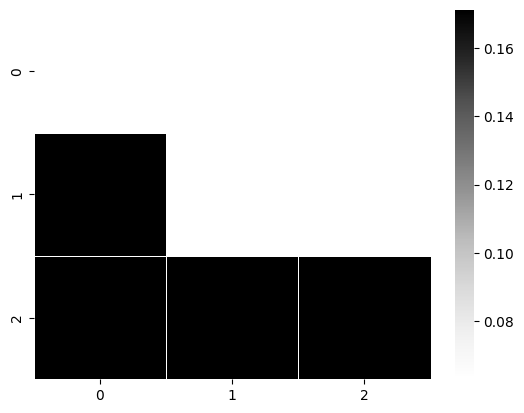

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.special import softmax

alphabet = [
    # A  B  C
    [1, 0, 0],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
]  # (strokes, cons)

clusters = [
    # A ,B, C
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
]  # (cons, clusters)

cluster_weight = [
    [0.0],
    [0.0],
    [1.0],
]  # (cluster, weight)

strokes = np.matmul(
    alphabet,  # (strokes, cons)
    clusters,  # (cons, clusters)
)  # (strokes, clusters)

strokes = strokes.transpose()  # (clusters, strokes)

pixel_ref = np.matrix(
    [
        [1.0, 0.0, 0.0, 0.0],
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        # removed row
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 0.0, 1.0],
    ]
).transpose()  # (strokes, pixels)

cluster_px = np.matmul(
    strokes,  # (clusters, strokes)
    pixel_ref,  # (strokes, pixels)
)  # (clusters, pixels)

cluster_px = cluster_px.transpose()  # (pixels, clusters)

pixels = np.matmul(
    cluster_px,  # (pixels, clusters)
    cluster_weight,  # (cluster)
)


def entropy_loss(output):
    """Computes the negative entropy loss to encourage uniformity (NumPy version)."""
    probs = softmax(output)
    entropy = -np.sum(probs * np.log(probs + 1e-8), axis=-1)  # Compute entropy
    return -np.mean(entropy)


loss = entropy_loss(pixels)
print("loss:", loss)

print(pixels)
pixels = softmax(np.insert(pixels, 2 * 2, 0)).reshape(3, 3)
print(pixels)
sns.heatmap(pixels, cmap="Greys", linewidths=0.5, cbar=True)
plt.show()

loss: -0.25821450232015286


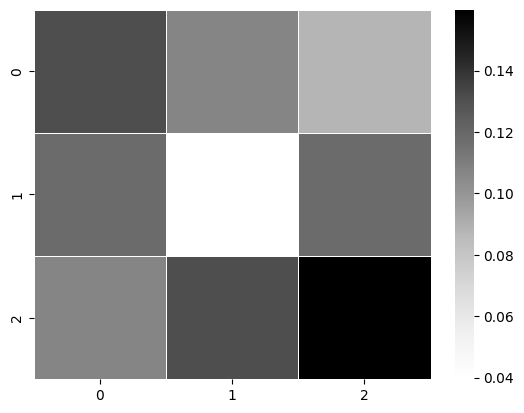

In [25]:
def compute_weights(alphabet):
    clusters = [[1, 0, 1], [0, 1, 0], [0, 0, 1]]  # (cons, clusters)
    cluster_weights = [[1.0], [0.8], [0.2]]  # (cluster, weight)
    pixel_ref = np.matrix(
        [
            [1.0, 0.0, 0.0, 0.0],
            [0.5, 0.5, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0],
            [0.5, 0.0, 0.5, 0.0],
            [0.0, 0.5, 0.0, 0.5],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.5, 0.5],
            [0.0, 0.0, 0.0, 1.0],
        ]
    ).transpose()

    strokes = np.matmul(alphabet, clusters).transpose()
    cluster_px = np.matmul(strokes, pixel_ref).transpose()
    return np.matmul(cluster_px, cluster_weights)


def entropy_loss(output):
    probs = softmax(output)
    entropy = -np.sum(probs * np.log(probs + 1e-8), axis=-1)  # Compute entropy
    return -np.mean(entropy)


def visualize_results(weights):
    weights = softmax(np.insert(weights, 2 * 2, 0)).reshape(3, 3)
    sns.heatmap(weights, cmap="Greys", linewidths=0.5, cbar=True)
    plt.show()


alphabet = [[1, 0, 0], [0, 1, 0], [0, 1, 1], [1, 0, 1]]
weights = compute_weights(alphabet)
loss = entropy_loss(weights)

print("loss:", loss)
visualize_results(weights)

In [29]:
import numpy as np
from scipy.special import softmax
from scipy.optimize import minimize


def compute_weights(alphabet, cluster_weights):
    alphabet = np.array(alphabet)  # Ensure alphabet is a NumPy array
    clusters = [[1, 0, 1], [0, 1, 0], [0, 0, 1]]  # (cons, clusters)
    pixel_ref = np.matrix(
        [
            [1.0, 0.0, 0.0, 0.0],
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            # removed row
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 1.0],
        ]
    ).transpose()

    strokes = np.matmul(alphabet, clusters).transpose()
    cluster_px = np.matmul(strokes, pixel_ref).transpose()
    px_weights = np.matmul(cluster_px, cluster_weights)
    return np.square(px_weights)


def entropy_loss(output):
    probs = softmax(output, axis=0)  # Apply softmax across the correct axis
    entropy = -np.sum(probs * np.log(probs + 1e-8), axis=-1)  # Compute entropy
    return -np.mean(entropy)


def objective_function(x):
    """Objective function to minimize (negative entropy loss)."""
    # Reshape x back into the alphabet matrix
    alphabet = x.reshape((4, 3))
    cluster_weights = np.array([[0.6], [0.3], [0.1]])  # (cluster, weight)
    weights = compute_weights(alphabet, cluster_weights)
    loss = entropy_loss(weights)
    return loss


# Initial guess for the alphabet matrix
initial_alphabet = np.random.rand(4, 3)
print(initial_alphabet)
initial_alphabet = np.array(initial_alphabet).flatten()  # Flatten for optimization

# Bounds for each element of the alphabet matrix (optional but recommended)
bounds = [(0, 5)] * 12  # Each element in alphabet matrix

# Optimization using scipy.optimize.minimize
result = minimize(
    objective_function, initial_alphabet, method="L-BFGS-B", bounds=bounds
)  # L-BFGS-B handles bounds better

# Extract the optimized alphabet
optimized_alphabet = result.x.reshape((4, 3))

print("Optimized Alphabet:")
print(optimized_alphabet)
print("\nMinimum Loss:", result.fun)

[[0.60389527 0.63258962 0.99200276]
 [0.17840955 0.21162083 0.83885135]
 [0.23314936 0.64524261 0.67867827]
 [0.91408723 0.18378154 0.10562055]]
Optimized Alphabet:
[[0.34673029 0.5223809  0.95527265]
 [0.44245461 0.32478853 0.87658019]
 [0.31653155 0.68098587 0.69059294]
 [0.66431598 0.07673374 0.0699381 ]]

Minimum Loss: -0.2599301823227633


--- INITIAL ---
[[0.3646895  0.3646895  0.03182997]
 [0.05435862 0.         0.03182997]
 [0.05435862 0.83555546 0.83555546]]


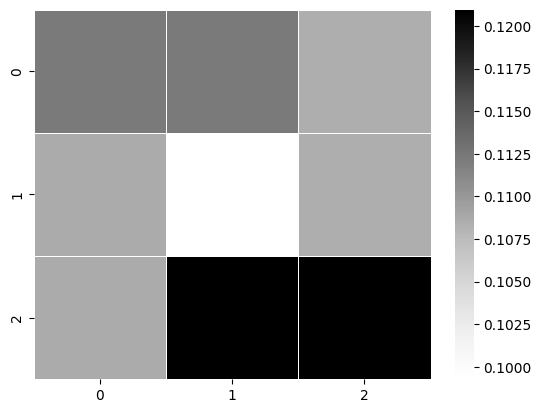

--- FINAL ---
[[0.12022189 0.12022189 0.19576608]
 [0.10019222 0.         0.19576608]
 [0.10019222 0.44131572 0.44131572]]


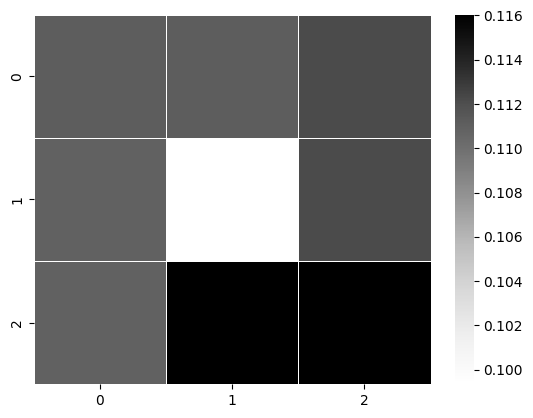

In [34]:
cluster_weights = np.array([[1.0], [0.0], [0.0]])  # (cluster, weight)

print("--- INITIAL ---")
weights = compute_weights(initial_alphabet.reshape(4, 3), cluster_weights)
print(np.insert(weights, 2 * 2, 0).reshape(3, 3))
visualize_results(softmax(weights))

print("--- FINAL ---")
weights = compute_weights(optimized_alphabet, cluster_weights)
print(np.insert(weights, 2 * 2, 0).reshape(3, 3))
visualize_results(softmax(weights))

# Entropy

In [21]:
import numpy as np
from scipy.stats import entropy


def calculate_entropy(data, base=None):
    """
    Calculates the entropy of a distribution.

    Args:
        data (array-like): The data representing the distribution.
        base (float, optional): The logarithmic base to use, defaults to e (natural logarithm).

    Returns:
        float: The entropy of the distribution.
    """
    probabilities = np.unique(data, return_counts=True)[1] / len(data)
    return entropy(probabilities, base=base)


# Example usage:
data = np.array([1, 5, 0, 0, 0, 0])
entropy_value = calculate_entropy(data)
print(f"Entropy: {entropy_value}")

Entropy: 0.8675632284814613


In [60]:
test = np.matrix([
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 1.0],
])
np.dot(test, test.transpose())

matrix([[1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 1., 1.]])